In [10]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch

from diffusers import StableDiffusionXLPipeline
from safetensors.torch import load_file
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize as sk_normalize
from transformers import (
    CLIPTokenizer,
    CLIPTextModel,
    CLIPTextModelWithProjection,
)

# 0. Settings
# device = "cuda:5"
dtype = torch.float
MODEL = model_id = "stabilityai/stable-diffusion-xl-base-1.0"

In [11]:
def load_embedding(tokenizer, text_encoder, state_dict, placeholder=None):
    assert os.path.exists(state_dict), f"File not found: {state_dict}"
    if not isinstance(state_dict, dict):
        state_dict = load_file(state_dict)

    # Load single token embedding.
    # if placeholder is not None:
    #     key = placeholder
    # else:  # default to the first key.
    #     key = list(state_dict.keys())[0]
    # embs = state_dict[key]
    # tokens = [key]
    # for i in range(1, embs.size(0)):
    #     tokens.append(f"{key}_{i}")
    # tokenizer.add_tokens(tokens)
    # text_encoder.resize_token_embeddings(len(tokenizer))
    # token_ids = tokenizer.convert_tokens_to_ids(tokens)
    # embeddings = text_encoder.get_input_embeddings().weight.data
    # for id, emb in zip(token_ids, embs):
    #     embeddings[id] = emb.clone()
    # identifier = " ".join(tokens)
    # return identifier

    # Load multiple token embeddings.
    identifiers = []
    for key, embs in state_dict.items():
        if placeholder is not None:
            key = placeholder
        tokens = [key]
        for i in range(1, embs.size(0)):
            tokens.append(f"{key}_{i}")
        tokenizer.add_tokens(tokens)
        text_encoder.resize_token_embeddings(len(tokenizer))
        token_ids = tokenizer.convert_tokens_to_ids(tokens)
        embeddings = text_encoder.get_input_embeddings().weight.data
        for id, emb in zip(token_ids, embs):
            embeddings[id] = emb.clone()
        identifier = " ".join(tokens)
        identifiers.append(identifier)
    return identifiers


def load_ti_embedding(embedding, embedding_2):
    tokenizer = CLIPTokenizer.from_pretrained(
        MODEL,
        subfolder="tokenizer",
    )
    text_encoder = CLIPTextModel.from_pretrained(
        MODEL,
        subfolder="text_encoder",
    )

    tokenizer_2 = CLIPTokenizer.from_pretrained(
        MODEL,
        subfolder="tokenizer_2",
    )
    text_encoder_2 = CLIPTextModelWithProjection.from_pretrained(
        MODEL,
        subfolder="text_encoder_2",
    )

    identifier = load_embedding(
        tokenizer,
        text_encoder,
        embedding,
    )

    identifier = load_embedding(
        tokenizer_2,
        text_encoder_2,
        embedding_2,
    )

    return (
        tokenizer,
        text_encoder,
        tokenizer_2,
        text_encoder_2,
        identifier,
    )

In [12]:
subject = "cat2"

# Embedding set 1: DTIR
# embedding_dti = f"../output/dtir-sdxlbase-lr5e-3/{subject}/learned_embeds-steps-1000.safetensors"
# embedding_dti_2 = f"../output/dtir-sdxlbase-lr5e-3/{subject}/learned_embeds_2-steps-1000.safetensors"
embedding_dti = f"../output/dtir-sdxlbase-rsgd_lr25-20/{subject}/learned_embeds-steps-1000.safetensors"
embedding_dti_2 = f"../output/dtir-sdxlbase-rsgd_lr25-20/{subject}/learned_embeds_2-steps-1000.safetensors"

# Embedding set 2: TI baseline
# embedding_ti = f"../output/ti-sdxlbase/{subject}/learned_embeds.safetensors"
# embedding_ti_2 = f"../output/ti-sdxlbase/{subject}/learned_embeds_2.safetensors"
embedding_ti = f"../output/ti-sdxlbase-768/{subject}/learned_embeds.safetensors"
embedding_ti_2 = f"../output/ti-sdxlbase-768/{subject}/learned_embeds_2.safetensors"

tokens_to_visualize = [
    "cat",
    "dog",
    "tiger",
    "kitten",
    "puppy",
    "lion",
    "wolf",
    "smile",
    "leopard",
    "gray",
    "happy",
    "green",
    "raccoon",
    "emoji",
    "forest",
    "jungle",
    "grass",
    "sad",
    "sleeping",
    "jumping",
    "sitting",
    "walking",
    "tail",
    "angry",
    "ears",
]
print(len(tokens_to_visualize), "tokens to visualize")

# 1. Load model/tokenizer and both embeddings
# pipe = StableDiffusionXLPipeline.from_pretrained(model_id, torch_dtype=dtype)
tokenizer, text_encoder_dti, _, _, identifier_dti_raw = load_ti_embedding(
    embedding_dti, embedding_dti_2
)
_, text_encoder_ti, _, _, identifier_ti_raw = load_ti_embedding(
    embedding_ti, embedding_ti_2
)

identifier_dti = f"{identifier_dti_raw[0]}-dti"
identifier_ti = f"{identifier_ti_raw[0]}-ti"
identifier_token = identifier_dti_raw[0]  # raw token string <cat2>

# 2. Get embeddings from DTI encoder
input_tokens = tokens_to_visualize + [identifier_token]
input_ids = tokenizer(input_tokens, return_tensors="pt", padding=True).input_ids

text_encoder_dti = text_encoder_dti.eval()
with torch.no_grad():
    outputs_dti = text_encoder_dti(input_ids, output_hidden_states=True)
    last_hidden_dti = outputs_dti.last_hidden_state

token_embeddings = []
labels = []

# 3. Extract embeddings from DTI tokens
for i, token in enumerate(input_tokens):
    tokenized = tokenizer(token, return_tensors="pt").input_ids[0]
    idx = (
        (input_ids[i] == tokenized[1]).nonzero(as_tuple=True)[0]
        if len(tokenized) > 1
        else torch.tensor([1])
    )
    embedding = last_hidden_dti[i, idx[0]].detach().cpu().numpy()
    if token == identifier_token:
        # labels.append(identifier_dti)  # rename for display
        labels.append("DTI")
    else:
        labels.append(token)
    token_embeddings.append(embedding)

# 4. Get TI version of the identifier
text_encoder_ti = text_encoder_ti.eval()
input_ids_ti = tokenizer(identifier_token, return_tensors="pt").input_ids

with torch.no_grad():
    outputs_ti = text_encoder_ti(input_ids_ti, output_hidden_states=True)
    last_hidden_ti = outputs_ti.last_hidden_state

idx_ti = (input_ids_ti[0] == input_ids_ti[0][1]).nonzero(as_tuple=True)[0]
embedding_ti = last_hidden_ti[0, idx_ti[0]].detach().cpu().numpy()

token_embeddings.append(embedding_ti)
# labels.append(identifier_ti)
labels.append("TI")

# 5. Stack and normalize
embeddings_np = np.stack(token_embeddings)
embeddings_norm = sk_normalize(embeddings_np, axis=1)

# 6. PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_norm)
embeddings_circle = sk_normalize(embeddings_2d, axis=1)

25 tokens to visualize


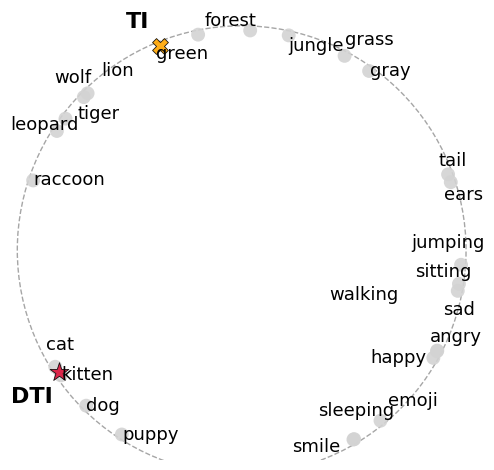

In [13]:
from adjustText import adjust_text

fig, ax = plt.subplots()
color_map = {"dti": "crimson", "ti": "orange", "others": "lightgray"}
texts = []
for i, label in enumerate(labels):
    x, y = embeddings_circle[i, 0], embeddings_circle[i, 1]

    # 강제로 원 내부로 클램핑 (norm이 1 초과되면 0.98로 스케일링)
    norm = np.sqrt(x**2 + y**2)
    if norm > 0.98:
        x, y = x * 0.98 / norm, y * 0.98 / norm

    if label == "DTI":
        color = color_map["dti"]
        marker = "*"
        size = 200
        edge = "black"
        # 밖으로 라벨을 이동
        text_x, text_y = x * 1.08, y * 1.08
        weight = "bold"
        fontsize = 16
    elif label == "TI":
        color = color_map["ti"]
        marker = "X"
        size = 130
        edge = "black"
        # 밖으로 라벨을 이동
        text_x, text_y = x * 1.08, y * 1.08
        weight = "bold"
        fontsize = 16
    else:
        color = color_map["others"]
        marker = "o"
        size = 100
        edge = "none"
        text_x, text_y = x, y
        weight = "normal"
        fontsize = 13

    ax.scatter(
        x,
        y,
        color=color,
        marker=marker,
        s=size,
        edgecolor=edge,
        linewidth=0.6,
        alpha=0.9,
        zorder=2,
    )

    texts.append(
        ax.text(
            text_x,
            text_y,
            label,
            fontsize=fontsize,
            fontweight=weight,
            ha="center",
            va="center",
        )
    )

# 라벨 자동 조정
adjust_text(
    texts,
    arrowprops=None,
    force_points=0.2,
    force_text=0.2,
    expand_text=(1.0, 1.1),
    only_move={"points": "none", "text": "xy"},
)

# Unit circle
circle = plt.Circle(
    (0, 0), 1, color="gray", fill=False, linestyle="--", linewidth=1, alpha=0.7
)
ax.add_artist(circle)

# Plot formatting
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

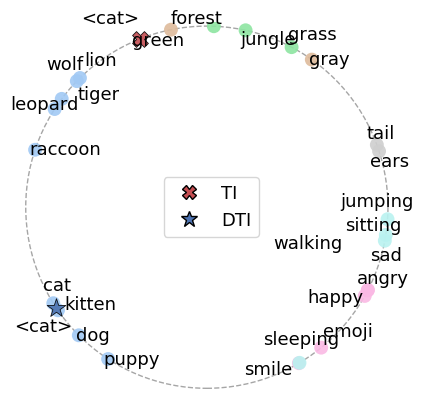

In [38]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# 카테고리 정의
category_map = {
    "cat": "animal",
    "kitten": "animal",
    "tiger": "animal",
    "lion": "animal",
    "leopard": "animal",
    "dog": "animal",
    "puppy": "animal",
    "wolf": "animal",
    "raccoon": "animal",
    "happy": "emotion",
    "sad": "emotion",
    "angry": "emotion",
    "smile": "emotion",
    "emoji": "emotion",
    "green": "color",
    "gray": "color",
    "forest": "nature",
    "jungle": "nature",
    "grass": "nature",
    "sleeping": "action",
    "jumping": "action",
    "sitting": "action",
    "walking": "action",
    "tail": "part",
    "ears": "part",
}
group_circle_colors = {
    # "animal": "turquoise",
    # "emotion": "pink",
    # "color": "khaki",
    # "nature": "darkolivegreen",
    # "action": "lightsteelblue",
    # "part": "gray"
    "animal": "#a1c9f4",
    "emotion": "#fab9e4",
    "color": "#debb9b",
    "nature": "#8de5a1",
    "action": "#b9f2f0",
    "part": "#cfcfcf",
}
special_color_map = {"dti": "#4c72b0", "ti": "#c44e52", "others": "#8c8c8c"}

fig, ax = plt.subplots()
texts = []

for i, label in enumerate(labels):
    x, y = embeddings_circle[i, 0], embeddings_circle[i, 1]

    norm = np.sqrt(x**2 + y**2)
    if norm > 0.98:
        x, y = x * 0.98 / norm, y * 0.98 / norm

    display_text = label
    weight = "normal"
    fontsize = 13

    if label == "DTI":
        color = special_color_map["dti"]
        marker = "*"
        size = 200
        edge = "black"
        display_text = "<cat>"
        text_x, text_y = x * 1.08, y * 1.08  # Always outside
    elif label == "TI":
        color = special_color_map["ti"]
        marker = "X"
        size = 130
        edge = "black"
        display_text = "<cat>"
        text_x, text_y = x * 1.08, y * 1.08  # Always outside
    else:
        category = category_map.get(label, "others")
        color = group_circle_colors.get(category, special_color_map["others"])
        marker = "o"
        size = 100
        edge = "none"
        text_x, text_y = x, y

    ax.scatter(
        x,
        y,
        color=color,
        marker=marker,
        s=size,
        edgecolor=edge,
        linewidth=0.6,
        alpha=0.9,
        zorder=2,
    )

    texts.append(
        ax.text(
            text_x,
            text_y,
            display_text,
            fontsize=fontsize,
            fontweight=weight,
            ha="center",
            va="center",
        )
    )

# 라벨 자동 조정
adjust_text(
    texts,
    arrowprops=None,
    force_points=0.2,
    force_text=0.2,
    expand_text=(1.0, 1.1),
    only_move={"points": "none", "text": "xy"},
)

# Unit circle
circle = plt.Circle(
    (0, 0), 0.98, color="gray", fill=False, linestyle="--", linewidth=1, alpha=0.7
)
ax.add_artist(circle)

# Plot formatting
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend with matching fontsize
legend_elements = [
    plt.Line2D(
        [0],
        [0],
        marker="X",
        color="w",
        label="TI",
        markerfacecolor=special_color_map["ti"],
        markeredgecolor="black",
        markersize=10,
    ),
    plt.Line2D(
        [0],
        [0],
        marker="*",
        color="w",
        label="DTI",
        markerfacecolor=special_color_map["dti"],
        markeredgecolor="black",
        markersize=12,
    ),
]
ax.legend(handles=legend_elements, loc="center", fontsize=13)

# 저장 및 출력
plt.savefig("obs2.pdf", bbox_inches="tight", dpi=300)
# plt.tight_layout()
plt.ylim(-1.0, 1.0)
plt.show()

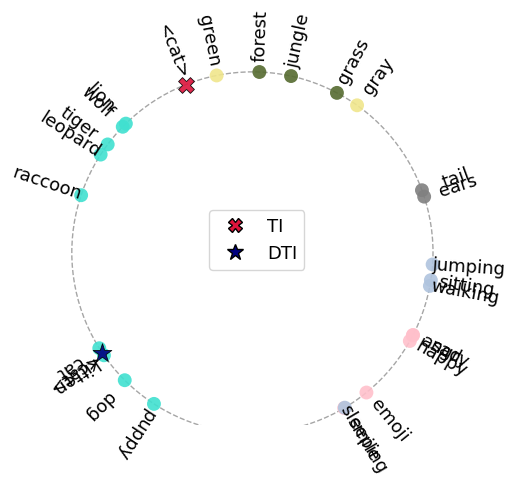

In [28]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import numpy as np

# 카테고리 정의
category_map = {
    "cat": "animal",
    "kitten": "animal",
    "tiger": "animal",
    "lion": "animal",
    "leopard": "animal",
    "dog": "animal",
    "puppy": "animal",
    "wolf": "animal",
    "raccoon": "animal",
    "happy": "emotion",
    "sad": "emotion",
    "angry": "emotion",
    "smile": "emotion",
    "emoji": "emotion",
    "green": "color",
    "gray": "color",
    "forest": "nature",
    "jungle": "nature",
    "grass": "nature",
    "sleeping": "action",
    "jumping": "action",
    "sitting": "action",
    "walking": "action",
    "tail": "part",
    "ears": "part",
}
group_circle_colors = {
    "animal": "turquoise",
    "emotion": "pink",
    "color": "khaki",
    "nature": "darkolivegreen",
    "action": "lightsteelblue",
    "part": "gray",
}
special_color_map = {"dti": "navy", "ti": "crimson", "others": "lightgray"}

fig, ax = plt.subplots()
texts = []

for i, label in enumerate(labels):
    x, y = embeddings_circle[i, 0], embeddings_circle[i, 1]

    norm = np.sqrt(x**2 + y**2)
    if norm > 0.98:
        x, y = x * 0.98 / norm, y * 0.98 / norm

    display_text = label
    weight = "normal"
    fontsize = 13

    angle_radians = np.arctan2(y, x)
    rotation = np.degrees(angle_radians)
    if 90 < rotation < 270:
        rotation += 180

    if label == "DTI":
        color = special_color_map["dti"]
        marker = "*"
        size = 200
        edge = "black"
        display_text = "<cat>"
        # text_x, text_y = x * 1.08, y * 1.08  # Always outside
    elif label == "TI":
        color = special_color_map["ti"]
        marker = "X"
        size = 130
        edge = "black"
        display_text = "<cat>"
        # text_x, text_y = x * 1.08, y * 1.08  # Always outside
    else:
        category = category_map.get(label, "others")
        color = group_circle_colors.get(category, special_color_map["others"])
        marker = "o"
        size = 100
        edge = "none"
        # text_x, text_y = x, y
    text_x, text_y = 1.2 * x, 1.2 * y

    ax.scatter(
        x,
        y,
        color=color,
        marker=marker,
        s=size,
        edgecolor=edge,
        linewidth=0.6,
        alpha=0.9,
        zorder=2,
    )

    texts.append(
        ax.text(
            text_x,
            text_y,
            display_text,
            fontsize=fontsize,
            fontweight=weight,
            ha="center",
            va="center",
            rotation=rotation,
            rotation_mode="anchor",
        )
    )

# 라벨 자동 조정
# adjust_text(
#     texts,
#     arrowprops=None,
#     force_points=0.2,
#     force_text=0.2,
#     expand_text=(1.0, 1.1),
#     only_move={'points': 'none', 'text': 'xy'},
# )

# Unit circle
circle = plt.Circle(
    (0, 0), 0.98, color="gray", fill=False, linestyle="--", linewidth=1, alpha=0.7
)
ax.add_artist(circle)

# Plot formatting
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend with matching fontsize
legend_elements = [
    plt.Line2D(
        [0],
        [0],
        marker="X",
        color="w",
        label="TI",
        markerfacecolor=special_color_map["ti"],
        markeredgecolor="black",
        markersize=10,
    ),
    plt.Line2D(
        [0],
        [0],
        marker="*",
        color="w",
        label="DTI",
        markerfacecolor=special_color_map["dti"],
        markeredgecolor="black",
        markersize=12,
    ),
]
ax.legend(handles=legend_elements, loc="center", fontsize=13)

# 저장 및 출력
plt.savefig("obs2.pdf", bbox_inches="tight", dpi=300)
# plt.tight_layout()
# plt.ylim(-1., 1.)
plt.show()